In [1]:
import os
import json

In [2]:
validation_annotations = json.load(
    open('./ai_challenger_caption_validation_20170910/caption_validation_annotations_20170910.json')
)


In [3]:
validation_annotations[1]

{'url': 'http://img.hexun.com/2011-06-09/130363655.jpg',
 'image_id': 'fb36d921dcd9184bdd4659864fe7f3cff47accf5.jpg',
 'caption': ['房间里一个右手放在嘴角的女人和一个戴着眼镜的男人在研究仪器',
  '一个披着长发的女人和一个戴着眼镜的男人站在室内的桌子旁',
  '室内有一个戴着眼镜的男人在向一个抬起右手的女人展示东西',
  '房间里有一个左手放在盒子上的男人在给一个右手食指放在嘴边的女人展示东西',
  '一个右手放在嘴边的女人和一个戴着眼镜的男人站在房间里']}

In [4]:
from PIL import Image
import requests
from transformers import ChineseCLIPProcessor, ChineseCLIPModel
import torch

# 官方 openai clip 不支持中文
# https://www.modelscope.cn/models/AI-ModelScope/chinese-clip-vit-base-patch16
model = ChineseCLIPModel.from_pretrained("/home/jiahaoli/modelscope/models/AI-ModelScope/chinese-clip-vit-base-patch16") # 中文clip模型
processor = ChineseCLIPProcessor.from_pretrained("/home/jiahaoli/modelscope/models/AI-ModelScope/chinese-clip-vit-base-patch16") # 预处理

/home/jiahaoli/.local/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [5]:
validation_annotations_dict = {x['image_id']: x['caption'][0] for x in validation_annotations}

In [21]:
import glob, json, os
from PIL import Image
from tqdm import tqdm_notebook
import numpy as np
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

img_paths = os.listdir('/home/jiahaoli/homework/Week10/ai_challenger_caption_validation_20170910/caption_validation_images_20170910')
img_paths = [os.path.join('/home/jiahaoli/homework/Week10/ai_challenger_caption_validation_20170910/caption_validation_images_20170910',x) for x in img_paths]

In [22]:
img_paths_basenames = [os.path.basename(x) for x in img_paths]
img_captions = [validation_annotations_dict[x] for x in img_paths_basenames]

In [23]:
img_image_feat = []

batch_size = 20
for idx in tqdm_notebook(range(len(img_captions) // batch_size + 1)):
    imgs = [Image.open(path) for path in img_paths[idx*batch_size: (idx+1)*batch_size] ]
    
    if len(imgs) == 0:
        break
    
    inputs = processor(images=imgs, return_tensors="pt")
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
        image_features = image_features.data.numpy()
        img_image_feat.append(image_features)

    break
        
img_image_feat = np.vstack(img_image_feat)
img_image_feat = normalize(img_image_feat)

/tmp/ipykernel_815768/2434997991.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for idx in tqdm_notebook(range(len(img_captions) // batch_size + 1)):


  0%|          | 0/1501 [00:00<?, ?it/s]

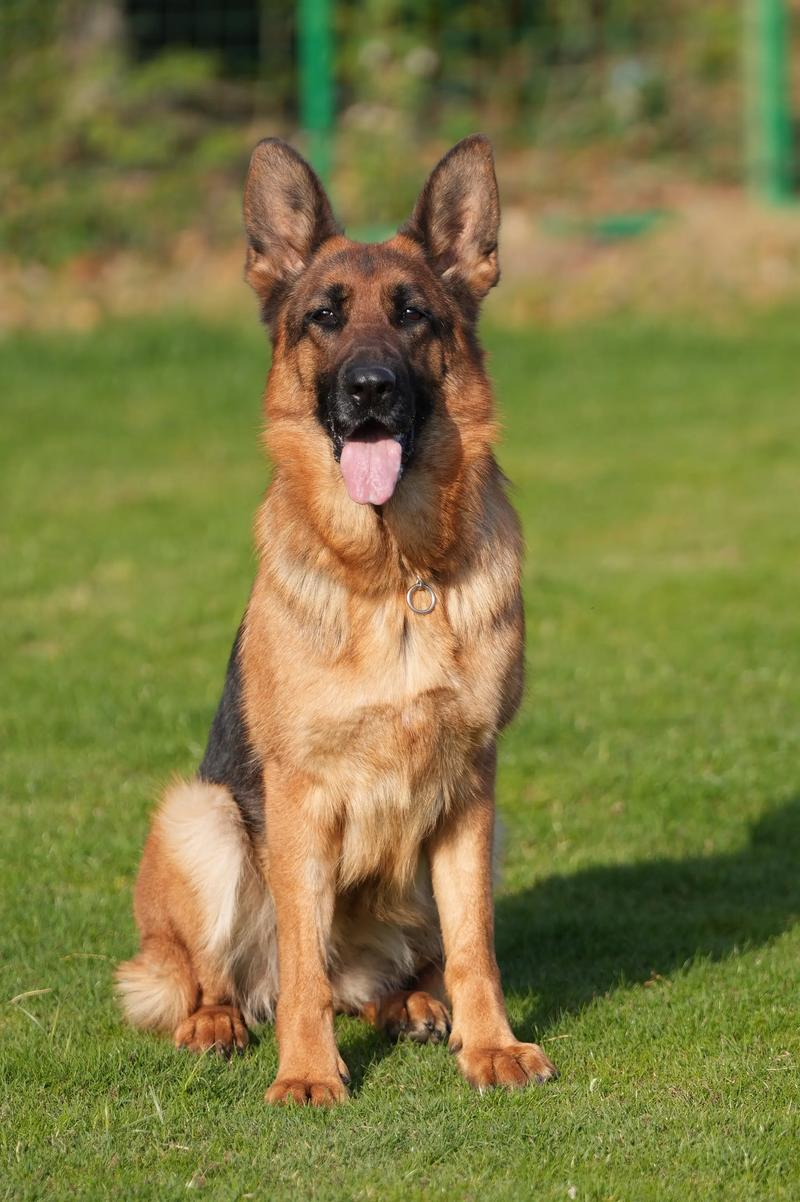

In [28]:
Image.open(image_path)

In [24]:
image_path = "./小狗图片.jpg"
img = [Image.open(image_path)]
input = processor(images=img, return_tensors='pt')
img_image_feat = []
with torch.no_grad():
    image_feature = model.get_image_features(**input)
    image_feature = image_feature.data.numpy()
    img_image_feat.append(image_feature)
img_image_feat = np.vstack(img_image_feat)
img_image_feat = normalize(img_image_feat)
img_texts_feat = []
texts = ['这是⼀只：⼩狗', '这是⼀只：⼩猫', '这是⼀只：⼩⻦', '这是⼀只：⻥', '这是⼀只：树']
inputs = processor(text=texts, return_tensors='pt', padding=True)
with torch.no_grad():
    text_features = model.get_text_features(**inputs)
    text_features = text_features.data.numpy()
    img_texts_feat.append(text_features)
img_texts_feat = np.vstack(img_texts_feat)
img_texts_feat = normalize(img_texts_feat)
print(img_texts_feat.shape)
sim_result = np.dot(img_image_feat[0], img_texts_feat.T)
sim_idx = sim_result.argsort()[::-1][0]

(5, 512)


In [26]:
print(texts[sim_idx])

这是⼀只：⼩狗
